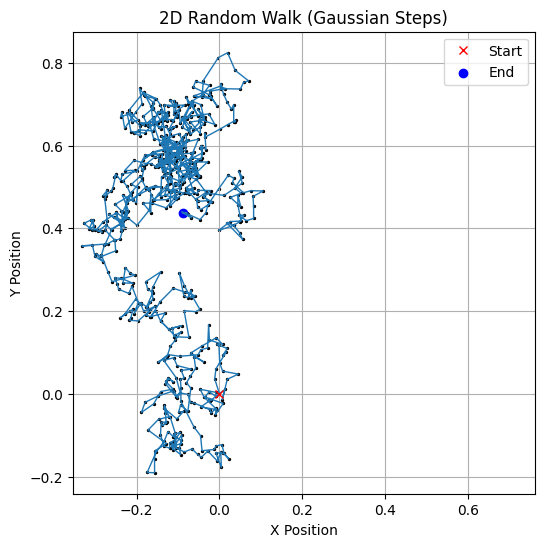

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# Parameters
num_steps = 726
num_walks = 400
std_dev = 0.02 # worth noting it is too random to analyse properly with std_dev over 0.5



# Store squared displacements
squared_displacements = np.zeros((num_walks, num_steps+1))


for w in range(num_walks):
    steps_x = np.random.normal(0, std_dev, num_steps) # when choosing these steps we are in tern choosing velocities
    steps_y = np.random.normal(0, std_dev, num_steps)

    x_positions = np.insert(np.cumsum(steps_x), 0, 0)
    y_positions = np.insert(np.cumsum(steps_y), 0, 0)

    squared_displacements[w] = x_positions**2 + y_positions**2



# Plot
plt.figure(figsize=(8,6))
plt.plot(x_positions, y_positions, lw=1, markersize=0.02)
plt.scatter(x_positions, y_positions, c='black', s=2)  # all points
plt.plot(0, 0, 'rx', label='Start')     # starting point
plt.scatter(x_positions[-1], y_positions[-1], c='blue', label='End')  # ending point
plt.xlabel("X Position")
plt.ylabel("Y Position")
plt.title("2D Random Walk (Gaussian Steps)")
plt.axis("square")
plt.legend()
plt.grid()
#lt.savefig("/Users/conorkirby/projects/python/capstone/Figures/Gaussian_rand_walk.png", dpi=300)
plt.show()

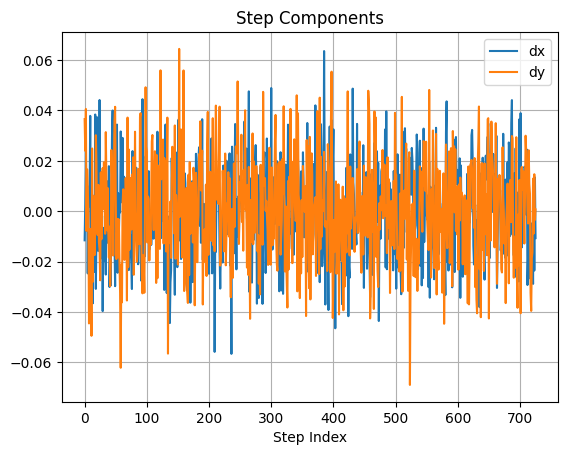

In [2]:
dx = np.diff(x_positions)
dy = np.diff(y_positions)

plt.plot(dx, label='dx')
plt.plot(dy, label='dy')
plt.legend()
plt.title("Step Components")
plt.xlabel("Step Index")
plt.grid()
plt.show()

step_mag = np.sqrt(dx**2 + dy**2)

#step_mag = step_mag[step_mag > 0]  # safety
log_returns = np.log(step_mag[1:] / step_mag[:-1])

volatility = np.abs(log_returns)

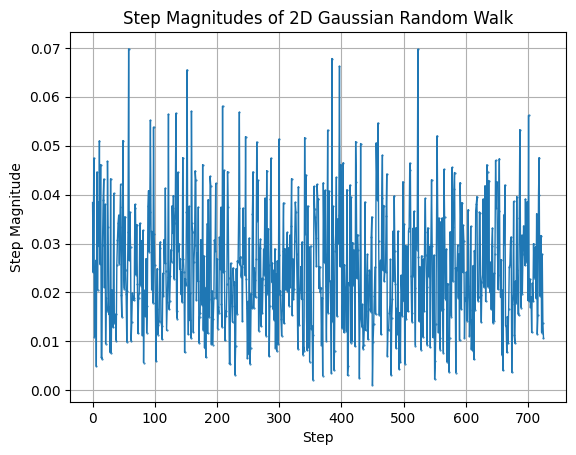

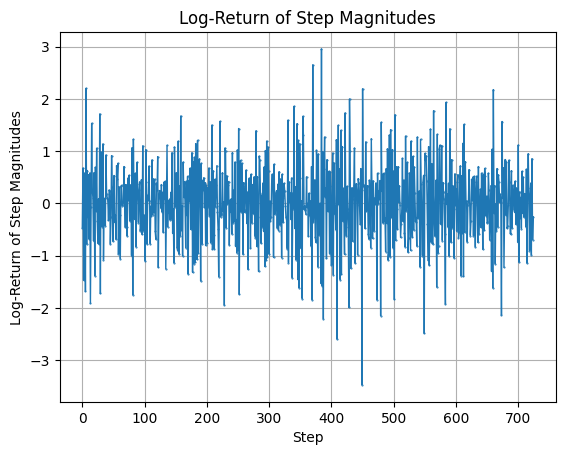

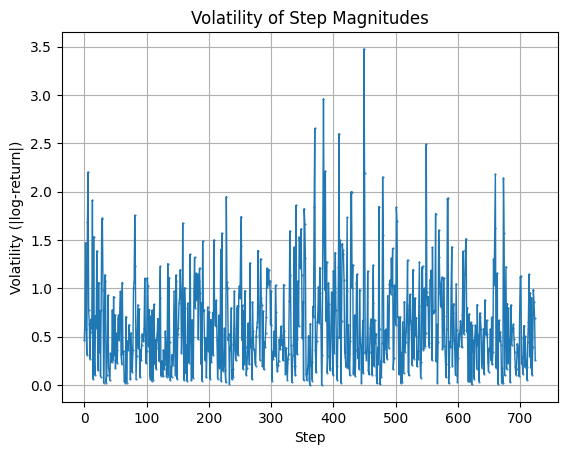

In [3]:
plt.plot(step_mag, marker='o', ms=0.5, lw=1)
plt.xlabel("Step")
plt.ylabel("Step Magnitude")
plt.title("Step Magnitudes of 2D Gaussian Random Walk")
plt.grid()
#plt.savefig("/Users/conorkirby/projects/python/capstone/Figures/Gaussian_volatility.png", dpi=300)
plt.show()

plt.plot(log_returns, marker='o', ms=0.5, lw=1)
plt.xlabel("Step")
plt.ylabel("Log-Return of Step Magnitudes")
plt.title("Log-Return of Step Magnitudes")
plt.grid()
#plt.savefig("/Users/conorkirby/projects/python/capstone/Figures/Gaussian_volatility.png", dpi=300)
plt.show()

plt.plot(volatility, marker='o', ms=0.5, lw=1)
plt.xlabel("Step")
plt.ylabel("Volatility (|log-return|)")
plt.title("Volatility of Step Magnitudes")
plt.grid()
#plt.savefig("/Users/conorkirby/projects/python/capstone/Figures/Gaussian_volatility.png", dpi=300)
plt.show()

In [4]:
def autocorr(x, max_lag):

    x = np.asarray(x)
    x = x - x.mean() # remove drift
    var = np.mean(x**2)

    acf = np.zeros(max_lag)
    for tau in range(max_lag):
        acf[tau] = np.mean(x[:-tau or None] * x[tau:]) / var

    return acf

""" def autocorr(x, max_lag):
    x = np.asarray(x)
    N = len(x)

    acf = np.zeros(max_lag)
    for tau in range(max_lag):
        acf[tau] = np.sum(x[:N-tau] * x[tau:]) / N

    return acf """

' def autocorr(x, max_lag):\n    x = np.asarray(x)\n    N = len(x)\n\n    acf = np.zeros(max_lag)\n    for tau in range(max_lag):\n        acf[tau] = np.sum(x[:N-tau] * x[tau:]) / N\n\n    return acf '

First autocorrilation calculates as 
$$C(\tau)
=
\frac{
\frac{1}{N-\tau}
\sum_{t=0}^{N-\tau-1}
\left(x_t - \bar{x}\right)\left(x_{t+\tau} - \bar{x}\right)
}{
\frac{1}{N}
\sum_{t=0}^{N-1}
\left(x_t - \bar{x}\right)^2
}
\qquad
(\tau \ge 0)$$

Second one as per book:
$$ C(\tau) = \frac{1}{N} \sum_{t=0}^{N-\tau-1} x(t)\,x(t+\tau) $$

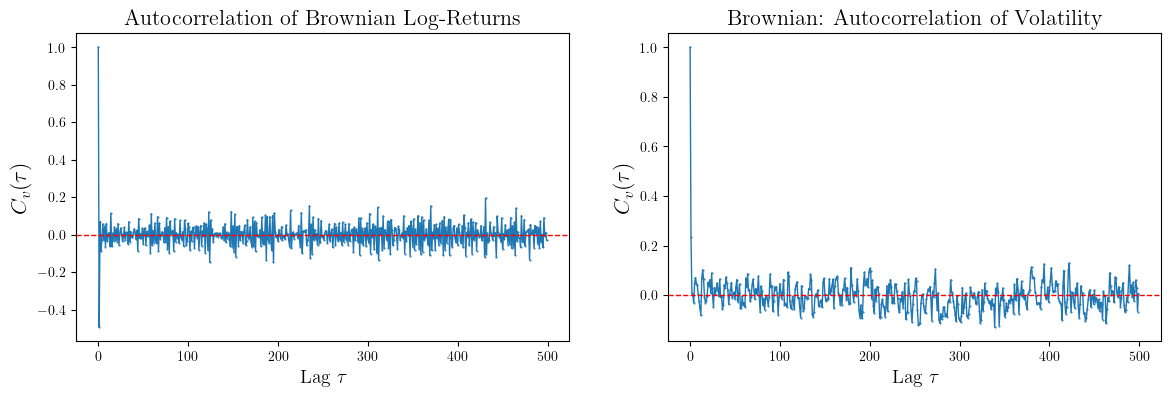

In [7]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Latin Modern Roman"],
})
fig, axs = plt.subplots(1, 2, figsize=(14,4))
axs = axs.ravel()

max_lag = 500  # choose based on dataset size
acf_vol = autocorr(volatility, max_lag)
acf_lr = autocorr(log_returns, max_lag)


axs[0].plot(acf_lr, lw=1, marker='o', ms=0.5)
axs[0].axhline(0, color='red', lw=1, ls='--')
#plt.xlim(0, 50)
#fit a linear line
axs[0].set_xlabel(r"Lag $\tau$", fontsize=14)
axs[0].set_ylabel(r"$C_v(\tau)$", fontsize=16)
axs[0].set_title("Autocorrelation of Brownian Log-Returns", fontsize=16)


axs[1].plot(acf_vol, lw=1, marker='o', ms=0.5)
axs[1].axhline(0, color='red', lw=1, ls='--')
#plt.xlim(0, 50)
#fit a linear line
axs[1].set_xlabel(r"Lag $\tau$", fontsize=14)
axs[1].set_ylabel(r"$C_v(\tau)$", fontsize=16)
axs[1].set_title("Brownian: Autocorrelation of Volatility", fontsize=16)
plt.savefig("/Users/conorkirby/Library/Mobile Documents/com~apple~CloudDocs/Coding/projects/python/capstone/Figures/00_Thesis_Figures/lr_volatility_acf_Brownian_1x2.png", dpi=300, bbox_inches='tight')
plt.show()